# Imports

In [1]:
import sys
sys.path.insert(0, "..")

In [22]:
from gates import LoadSquareSatelliteData
from gates.data.load_data import load_fps
import gates.data.datasets as gates_datasets

In [3]:
from vis_plotting.general_plotting import *
from vis_plotting.topog_plotting import *
from vis_plotting.met_plotting import *

# Wind roses

In [4]:
met_args = {"met_levels":[1], "met_variables":["x_wind", "y_wind"]}

In [15]:
data_india = LoadSquareSatelliteData(201401, freq=50, size=6, region="INDIA", load_everything=True, verbose=True, met_args=met_args)
measurement_idx = data_india.size//2

2026.3.0
---- LOADING FOOTPRINTS
Loading footprint data from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/fp_archive/INDIA/*SOUTHASIA*_201401*.nc
WITH CHUNKING -
reduced the number of datapoints by frequency 50
Loading 11 footprints
loaded fp variable into mem
----- Cutting footprints to square of size 6

 ---- LOADING MET
Loading meteorology from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/met_archive/INDIA/INDIA_Met_201401*.nc
WITH CHUNKING - met
Met file chunk stats:
Chunks: Frozen({'model_level_number': (1,), 'lat': (325,), 'lon': (235,), 'time': (8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8)})
Dataset size (GB): 0.303060236

---- LOADING TOPOG AND LANDCOVER
Loading topography from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
Loading landcover from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/LPDM/topog_NAME/land_cover.nc
loading both into memory
----- Cutting topog
----- Cutt

In [16]:
# print size of dataset in mb
data_india.met 
print(f"Size of dataset in MB: {data_india.met.nbytes / 1e6:.2f} MB")

Size of dataset in MB: 0.01 MB


In [17]:
data_india.met

<xarray.Dataset> Size: 7kB
Dimensions:         (levels: 1, time: 11, lat: 6, lon: 6, time_delta: 1)
Coordinates:
  * levels          (levels) int32 4B 1
    level_height    (levels) float32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    sigma           (levels) float32 4B dask.array<chunksize=(1,), meta=np.ndarray>
  * lat             (lat) int64 48B 0 1 2 3 4 5
  * lon             (lon) int64 48B 0 1 2 3 4 5
  * time            (time) datetime64[ns] 88B 2014-01-01T07:44:36 ... 2014-01...
  * time_delta      (time_delta) int64 8B 0
Data variables:
    x_wind          (levels, time, lat, lon) float32 2kB dask.array<chunksize=(1, 11, 6, 6), meta=np.ndarray>
    y_wind          (levels, time, lat, lon) float32 2kB dask.array<chunksize=(1, 11, 6, 6), meta=np.ndarray>
    met_timestamps  (time) datetime64[ns] 88B 2014-01-01T09:00:00 ... 2014-01...
    fp_time         (time) datetime64[ns] 88B 2014-01-01T07:44:36 ... 2014-01...
    lat_coords      (time, lat) float32 264B 32.68 32.91 33.14 ... 25.19 25.42
    lon_coords      (time, lon) float32 264B 78.23 78.58 78.94 ... 74.71 75.06
    wind_angle      (levels, time, lat, lon) float32 2kB dask.array<chunksize=(1, 11, 6, 6), meta=np.ndarray>
    wind_speed      (levels, time, lat, lon) float32 2kB dask.array<chunksize=(1, 11, 6, 6), meta=np.ndarray>
Attributes:
    author:           Jeff Clark (kr21883)
    created:          2025-07-10 18:41
    transformations:  interpolated linearly in space to NAME resolution

In [18]:
selected_met = data_india.met[["x_wind", "y_wind"]].sel(lat=measurement_idx, lon=measurement_idx, levels=1)
selected_met.load()

<xarray.Dataset> Size: 204B
Dimensions:       (time: 11)
Coordinates:
    levels        int32 4B 1
    level_height  float32 4B 20.0
    sigma         float32 4B 0.9977
    lat           int64 8B 3
    lon           int64 8B 3
  * time          (time) datetime64[ns] 88B 2014-01-01T07:44:36 ... 2014-01-2...
Data variables:
    x_wind        (time) float32 44B 1.364 0.8468 0.3585 ... 1.16 2.64 -0.2698
    y_wind        (time) float32 44B 0.5245 -1.835 1.536 ... -2.288 0.1153
Attributes:
    author:           Jeff Clark (kr21883)
    created:          2025-07-10 18:41
    transformations:  interpolated linearly in space to NAME resolution

<WindroseAxes: title={'center': 'Per-footprint Wind Rose \n Level 1'}>

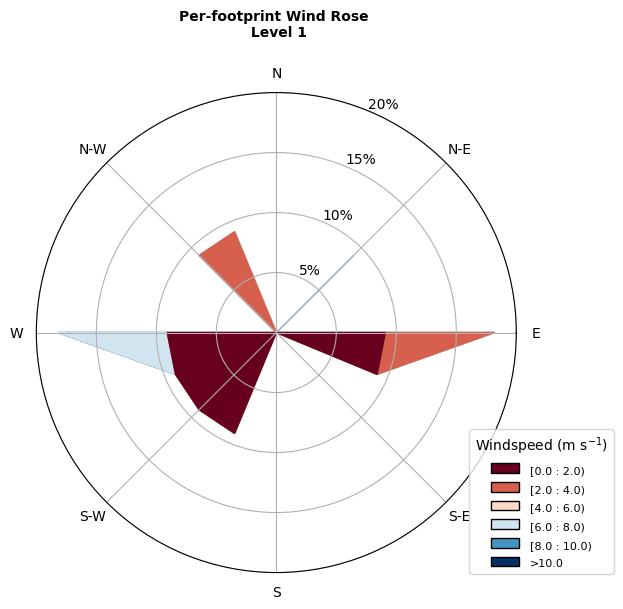

In [19]:
plot_single_windrose(data_india.met.sel(lat=measurement_idx, lon=measurement_idx, levels=1),  limit=20, legend=True, title=f"Per-footprint Wind Rose \n Level 1")

# FP Histograms

In [20]:
data_india = LoadSquareSatelliteData(2014, freq=50, size=50, region="INDIA", load_everything=False, verbose=True, met_args=met_args)

2026.3.0
---- LOADING FOOTPRINTS
Loading footprint data from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/fp_archive/INDIA/*SOUTHASIA*_2014*.nc
WITH CHUNKING -
reduced the number of datapoints by frequency 50
Loading 107 footprints
loaded fp variable into mem
----- Cutting footprints to square of size 50
Padding lat by (25, 0) cells (S, N) with mode='nans'
---- All done!


In [ ]:
fpds = gates_datasets.FootprintDataset(data_india.fp_xr, scaler=gates_datasets.LogAndShiftFpScaler, scaler_params={"minimum_oom": 5})
transformed_fps = fpds.fit_transform()

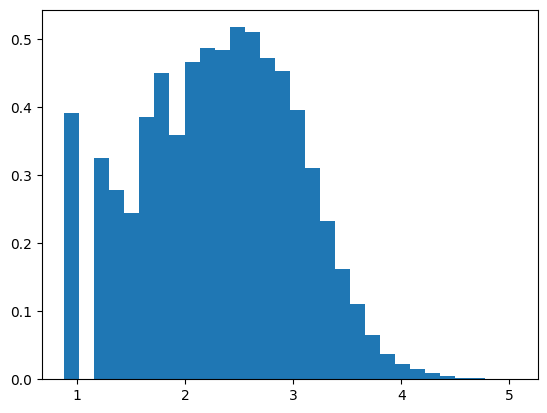

In [24]:
_ = plt.hist(transformed_fps.fp_transformed.values.flatten()[transformed_fps.fp_transformed.values.flatten()>0], bins=30, density=True)

# Do all months together

## Brazil

In [42]:
year = 2014
monthly_data = []

for month in range(1, 13):
    ym = int(f"{year}{month:02d}")
    try:
        d = LoadSquareSatelliteData(
            ym, freq=50, size=6, region="BRAZIL",
            load_everything=True, verbose=True, met_args=met_args,
        )
        monthly_data.append(d)
    except Exception as e:
        print(f"Failed to load {ym}: {e}")

# Concatenate the underlying xarray datasets along time
data_brazil_fp    = xr.concat([d.fp_xr        for d in monthly_data], dim="time").sortby("time")
data_brazil_met   = xr.concat([d.met          for d in monthly_data], dim="time").sortby("time")
data_india_topog = monthly_data[0].topog 

2026.3.0
---- LOADING FOOTPRINTS
Loading footprint data from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/fp_archive/SOUTHAMERICA/*BRAZIL*_201401*.nc
WITH CHUNKING -
reduced the number of datapoints by frequency 50
Loading 29 footprints
loaded fp variable into mem
----- Cutting footprints to square of size 6

 ---- LOADING MET
Loading meteorology from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/met_archive/SOUTHAMERICA/SOUTHAMERICA_Met_201401*.nc
WITH CHUNKING - met
Met file chunk stats:
Chunks: Frozen({'model_level_number': (1,), 'lat': (357,), 'lon': (239,), 'time': (8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8)})
Dataset size (GB): 0.507850844

---- LOADING TOPOG AND LANDCOVER
Loading topography from /mnt/shared/home/kr21883/GATES_LPDM_emulato

<WindroseAxes: title={'center': 'Per-footprint Wind Rose \n Level 1'}>

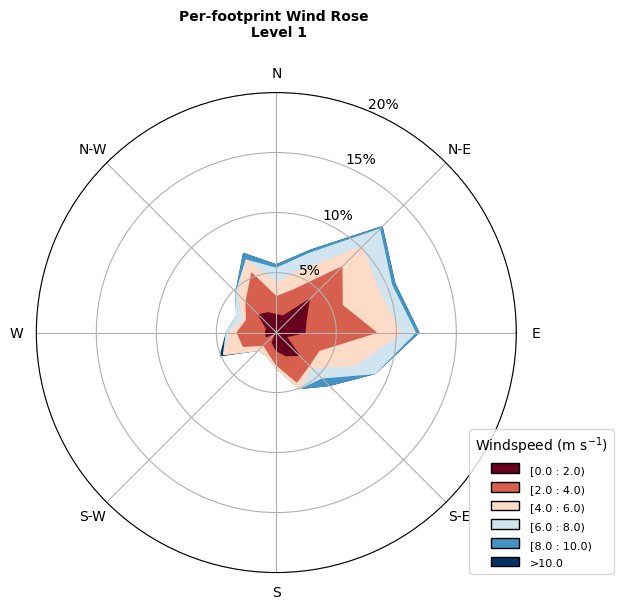

In [44]:
plot_single_windrose(data_brazil_met.sel(lat=measurement_idx, lon=measurement_idx, levels=1),  limit=20, legend=True, title=f"Per-footprint Wind Rose \n Level 1")

## India

In [ ]:
import xarray as xr

year = 2014
monthly_data = []

for month in range(1, 13):
    ym = int(f"{year}{month:02d}")
    try:
        d = LoadSquareSatelliteData(
            ym, freq=50, size=6, region="INDIA",
            load_everything=True, verbose=True, met_args=met_args,
        )
        monthly_data.append(d)
    except Exception as e:
        print(f"Failed to load {ym}: {e}")

# Concatenate the underlying xarray datasets along time
data_india_fp    = xr.concat([d.fp_xr        for d in monthly_data], dim="time").sortby("time")
data_india_met   = xr.concat([d.met          for d in monthly_data], dim="time").sortby("time")
data_india_topog = monthly_data[0].topog  # static — same for all months

2026.3.0
---- LOADING FOOTPRINTS
Loading footprint data from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/fp_archive/INDIA/*SOUTHASIA*_201401*.nc
WITH CHUNKING -
reduced the number of datapoints by frequency 50
Loading 11 footprints
loaded fp variable into mem
----- Cutting footprints to square of size 6

 ---- LOADING MET
Loading meteorology from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/met_archive/INDIA/INDIA_Met_201401*.nc
WITH CHUNKING - met
Met file chunk stats:
Chunks: Frozen({'model_level_number': (1,), 'lat': (325,), 'lon': (235,), 'time': (8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8)})
Dataset size (GB): 0.303060236

---- LOADING TOPOG AND LANDCOVER
Loading topography from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
Loading landcover from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/LPDM/topog_NAME/land_cover.nc
loading both into memory
----- Cutting topog
----- Cutt

<WindroseAxes: title={'center': 'Per-footprint Wind Rose \n Level 1'}>

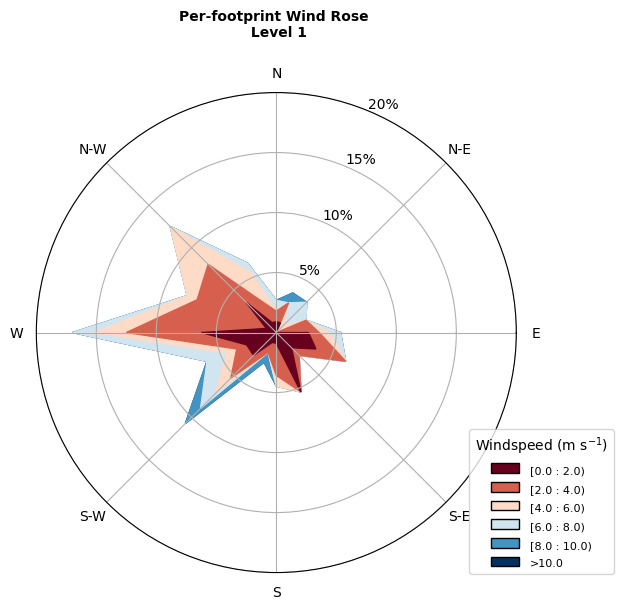

In [29]:
plot_single_windrose(data_india_met.sel(lat=measurement_idx, lon=measurement_idx, levels=1),  limit=20, legend=True, title=f"Per-footprint Wind Rose \n Level 1")

In [ ]:
fpds = gates_datasets.FootprintDataset(
    data_india_fp,                            # the xr.concat result from your monthly loop
    scaler=gates_datasets.LogAndShiftFpScaler,
    scaler_params={"minimum_oom": 5},
)
transformed_fps = fpds.fit_transform()

vals = transformed_fps.fp_transformed.values.flatten()
_ = plt.hist(vals[vals > 0], bins=30, density=True)

## China

In [30]:
year = 2014
monthly_data = []

for month in range(1, 13):
    ym = int(f"{year}{month:02d}")
    try:
        d = LoadSquareSatelliteData(
            ym, freq=50, size=6, region="CHINA",
            load_everything=True, verbose=True, met_args=met_args,
        )
        monthly_data.append(d)
    except Exception as e:
        print(f"Failed to load {ym}: {e}")

# Concatenate the underlying xarray datasets along time
data_china_fp    = xr.concat([d.fp_xr        for d in monthly_data], dim="time").sortby("time")
data_china_met   = xr.concat([d.met          for d in monthly_data], dim="time").sortby("time")
data_china_topog = monthly_data[0].topog  # static — same for all months

2026.3.0
---- LOADING FOOTPRINTS
Loading footprint data from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/fp_archive/CHINA/*EASTASIA*_201401*.nc
WITH CHUNKING -
reduced the number of datapoints by frequency 50
Loading 31 footprints
loaded fp variable into mem
----- Cutting footprints to square of size 6

 ---- LOADING MET
Loading meteorology from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/met_archive/CHINA/CHINA_Met_201401*.nc
WITH CHUNKING - met
Met file chunk stats:
Chunks: Frozen({'model_level_number': (1,), 'lat': (338,), 'lon': (348,), 'time': (8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8)})
Dataset size (GB): 0.233370756

---- LOADING TOPOG AND LANDCOVER
Loading topography from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
Loading landcover from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/LPDM/topog_NAME/land_cover.nc
loading both into memory
----- Cutting topog
----- Cutti

In [31]:
selected_met_china = data_china_met[["x_wind", "y_wind"]].sel(lat=measurement_idx, lon=measurement_idx, levels=1)
selected_met_china.load()

<xarray.Dataset> Size: 4kB
Dimensions:       (time: 227)
Coordinates:
    levels        int32 4B 1
    level_height  float32 4B 20.0
    sigma         float32 4B 0.9977
    lat           int64 8B 3
    lon           int64 8B 3
  * time          (time) datetime64[ns] 2kB 2014-01-01T04:27:32 ... 2014-12-1...
Data variables:
    x_wind        (time) float32 908B 3.722 -0.7405 2.351 ... 4.558 -0.2837
    y_wind        (time) float32 908B 0.2665 1.163 -2.013 ... -0.8774 -1.153
Attributes:
    author:           Jeff Clark (kr21883)
    created:          2026-04-19 19:37
    transformations:  interpolated linearly in space to NAME resolution

<WindroseAxes: title={'center': 'Per-footprint Wind Rose \n Level 1'}>

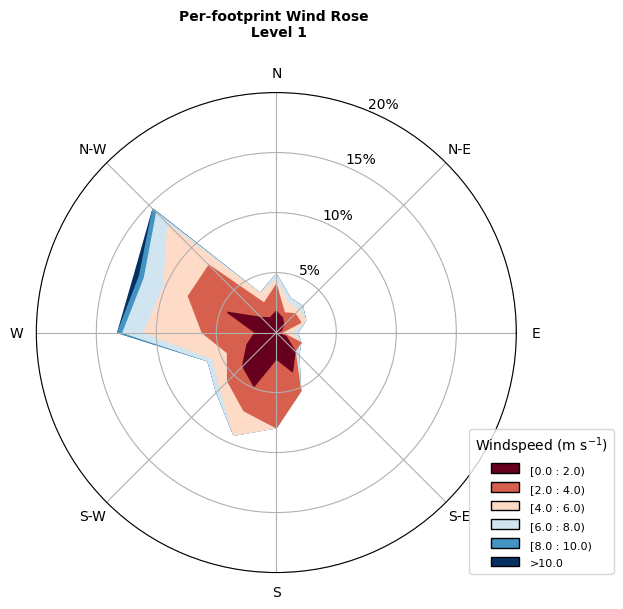

In [32]:
plot_single_windrose(data_china_met.sel(lat=measurement_idx, lon=measurement_idx, levels=1),  limit=20, legend=True, title=f"Per-footprint Wind Rose \n Level 1")

In [47]:
# Check this gets the same result

plot_single_windrose(selected_met_china.sel(lat=measurement_idx, lon=measurement_idx, levels=1),  limit=20, legend=True, title=f"Per-footprint Wind Rose \n Level 1")

KeyError: "no index found for coordinate 'lat'"

## Sahara

In [33]:
year = 2014
monthly_data = []

for month in range(1, 13):
    ym = int(f"{year}{month:02d}")
    try:
        d = LoadSquareSatelliteData(
            ym, freq=50, size=6, region="SAHARA",
            load_everything=True, verbose=True, met_args=met_args,
        )
        monthly_data.append(d)
    except Exception as e:
        print(f"Failed to load {ym}: {e}")

# Concatenate the underlying xarray datasets along time
data_sahara_fp    = xr.concat([d.fp_xr        for d in monthly_data], dim="time").sortby("time")
data_sahara_met   = xr.concat([d.met          for d in monthly_data], dim="time").sortby("time")
data_sahara_topog = monthly_data[0].topog  # static — same for all months

2026.3.0
---- LOADING FOOTPRINTS
Loading footprint data from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/fp_archive/NORTHAFRICA/*NORTHAFRICA*_201401*.nc
WITH CHUNKING -
reduced the number of datapoints by frequency 50
Loading 23 footprints
loaded fp variable into mem
----- Cutting footprints to square of size 6

 ---- LOADING MET
Loading meteorology from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/met_archive/NORTHAFRICA/NORTHAFRICA_Met_201401*.nc
WITH CHUNKING - met
Met file chunk stats:
Chunks: Frozen({'model_level_number': (1,), 'lat': (296,), 'lon': (320,), 'time': (8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8)})
Dataset size (GB): 0.18792894

---- LOADING TOPOG AND LANDCOVER
Loading topography from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
Loading landcover from /mnt/shared/home/kr21883/GATES_LPDM_emulator/data/LPDM/topog_NAME/land_cover.nc
loading both into memory
----- Cutti

In [34]:
selected_met_sahara = data_sahara_met[["x_wind", "y_wind"]].sel(lat=measurement_idx, lon=measurement_idx, levels=1)
selected_met_sahara.load()

<xarray.Dataset> Size: 4kB
Dimensions:       (time: 234)
Coordinates:
    levels        int32 4B 1
    level_height  float32 4B 20.0
    sigma         float32 4B 0.9977
    lat           int64 8B 3
    lon           int64 8B 3
  * time          (time) datetime64[ns] 2kB 2014-01-01T11:01:16 ... 2014-12-1...
Data variables:
    x_wind        (time) float32 936B 1.121 -0.4143 -3.626 ... 0.2457 -6.967
    y_wind        (time) float32 936B -1.157 -2.917 -5.407 ... -9.86 -8.002
Attributes:
    author:           Elena Fillola (ef17148)
    created:          2025-02-07 16:16
    transformations:  interpolated linearly in space to NAME resolution

<WindroseAxes: title={'center': 'Per-footprint Wind Rose \n Level 1'}>

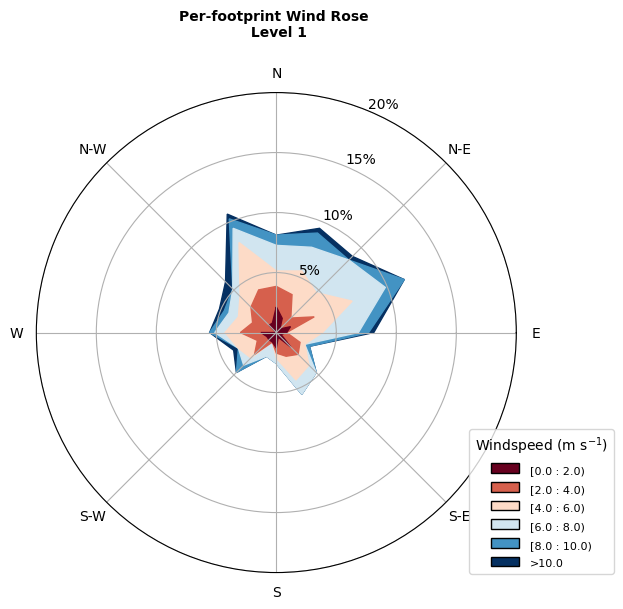

In [40]:
plot_single_windrose(data_sahara_met.sel(lat=measurement_idx, lon=measurement_idx, levels=1),  limit=20, legend=True, title=f"Per-footprint Wind Rose \n Level 1")

# Stacked histogram

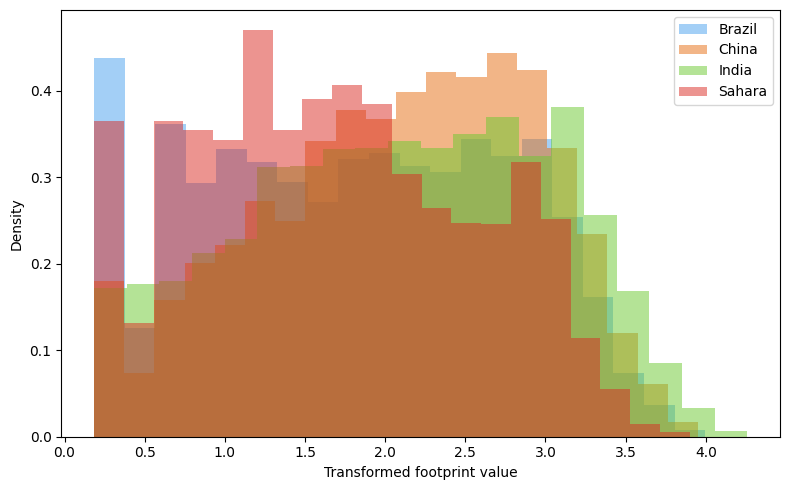

In [56]:
region_colours = {
    "BRAZIL": "#48A1EE",  # blue
    "CHINA":  "#E66D10",  # orange
    "INDIA":  "#6AC92F",  # green
    "SAHARA": "#DA2A23",  # muted red
}

regions = {
    "BRAZIL": data_brazil_fp,
    "CHINA":  data_china_fp,
    "INDIA":  data_india_fp,
    "SAHARA": data_sahara_fp,
}

fig, ax = plt.subplots(figsize=(8, 5))

for region_name, fp_data in regions.items():
    fpds = gates_datasets.FootprintDataset(
        fp_data,
        scaler=gates_datasets.LogAndShiftFpScaler,
        scaler_params={"minimum_oom": 5},
    )
    transformed = fpds.fit_transform()
    vals = transformed.fp_transformed.values.flatten()
    ax.hist(vals[vals > 0], bins=20, density=True,
            #histtype="step", linewidth=2, 
            alpha=0.5, label=f"{region_name.capitalize()}",
            color=region_colours[region_name])

ax.set_xlabel("Transformed footprint value")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("fp_histogram_overlay_four_regions_outline.png", bbox_inches='tight')
plt.show()

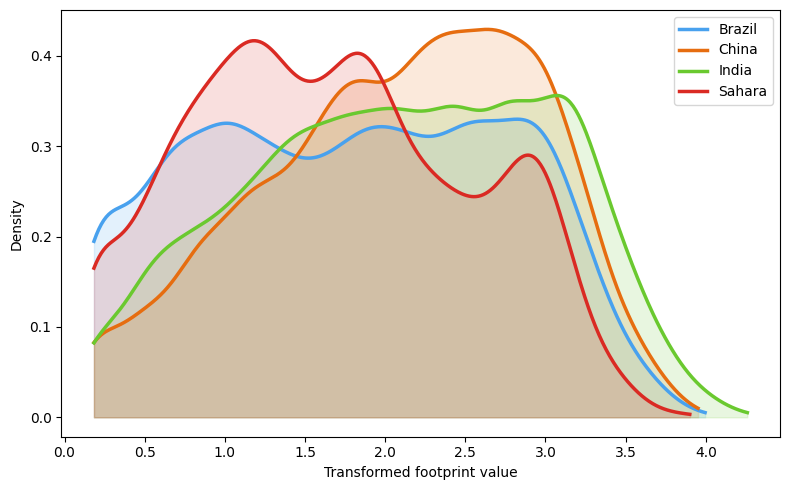

In [55]:
from scipy.stats import gaussian_kde
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

for region_name, fp_data in regions.items():
    fpds = gates_datasets.FootprintDataset(
        fp_data,
        scaler=gates_datasets.LogAndShiftFpScaler,
        scaler_params={"minimum_oom": 5},
    )
    transformed = fpds.fit_transform()
    vals = transformed.fp_transformed.values.flatten()
    vals = vals[vals > 0]

    kde = gaussian_kde(vals, bw_method=0.15)
    x = np.linspace(vals.min(), vals.max(), 500)
    ax.plot(x, kde(x), label=region_name.capitalize(),
            color=region_colours[region_name], linewidth=2.5)
    ax.fill_between(x, kde(x), alpha=0.15, color=region_colours[region_name])

ax.set_xlabel("Transformed footprint value")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("fp_histogram_overlay_four_regions_kde.png", bbox_inches="tight")
plt.show()